# Measures of Lexical Distinctiveness, Similarity, and Syntactic Complexity

In [1]:
# packages
import duckdb
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load Data

In [2]:
con = duckdb.connect("../guardian_articles.duckdb")
df = con.execute("SELECT * FROM sample_articles").fetchdf()

In [3]:
df.columns

Index(['id', 'type', 'sectionId', 'sectionName', 'webPublicationDate',
       'webTitle', 'webUrl', 'apiUrl', 'body', 'isHosted', 'pillarId',
       'pillarName', 'headline', 'shortUrl', 'search_terms', 'pull_date',
       'clean_body', 'search_term', 'rn'],
      dtype='object')

In [4]:
df.head()

,id,type,sectionId,sectionName,webPublicationDate,webTitle,webUrl,apiUrl,body,isHosted,pillarId,pillarName,headline,shortUrl,search_terms,pull_date,clean_body,search_term,rn
0,technology/2026/mar/19/amazon-uk-ai-upgrade-al...,article,technology,Technology,2026-03-19 06:00:03,‘All right mate?’: Amazon pins UK hopes on AI ...,https://www.theguardian.com/technology/2026/ma...,https://content.guardianapis.com/technology/20...,"<p>“Commiserations, mate, Chelsea lost 3-0 in ...",False,pillar/news,News,‘All right mate?’: Amazon pins UK hopes on AI ...,https://www.theguardian.com/p/x4jxqc,"AI, GenAI, generative AI",2026-04-04 19:35:08.106210,"“Commiserations, mate, Chelsea lost 3-0 in the...",GenAI,1
1,australia-news/article/2024/jul/30/australian-...,article,australia-news,Australia news,2024-07-29 15:00:44,Australian universities accused of awarding de...,https://www.theguardian.com/australia-news/art...,https://content.guardianapis.com/australia-new...,<p>International students who cannot speak “ba...,False,pillar/news,News,Australian universities accused of awarding de...,https://www.theguardian.com/p/xv2bve,"AI, GenAI, artificial intelligence, generative AI",2026-04-04 19:35:08.079939,International students who cannot speak “basic...,GenAI,2
2,society/2025/apr/28/commissioner-calls-for-ban...,article,society,Society,2025-04-28 08:00:56,Commissioner calls for ban on apps that make d...,https://www.theguardian.com/society/2025/apr/2...,https://content.guardianapis.com/society/2025/...,<p>Artificial intelligence “nudification” apps...,False,pillar/news,News,Commissioner calls for ban on apps that make d...,https://www.theguardian.com/p/x25a54,"AI, GenAI, artificial intelligence, generative AI",2026-04-04 19:35:08.076656,Artificial intelligence “nudification” apps th...,GenAI,3
3,help/insideguardian/2023/jun/16/the-guardians-...,article,help,Help,2026-03-04 12:56:53,The Guardian’s approach to generative AI,https://www.theguardian.com/help/insideguardia...,https://content.guardianapis.com/help/insidegu...,"<p>Over the last three months, colleagues from...",False,pillar/news,News,The Guardian’s approach to generative AI,https://www.theguardian.com/p/z8db6,"AI, GenAI, generative AI",2026-04-04 19:35:08.106602,"Over the last three months, colleagues from ou...",GenAI,4
4,tv-and-radio/2016/aug/08/monday-best-tv-naked-...,article,tv-and-radio,Television & radio,2016-08-08 05:20:24,Monday’s best TV: Naked Attraction; Brief Enco...,https://www.theguardian.com/tv-and-radio/2016/...,https://content.guardianapis.com/tv-and-radio/...,"<h2><strong>Brief Encounters </strong><br>9pm,...",False,pillar/arts,Arts,Monday’s best TV: Naked Attraction; Brief Enco...,https://www.theguardian.com/p/4ptpb,GenAI,2026-04-04 19:35:08.124571,"Brief Encounters 9pm, ITV The 80s-flavoured, k...",GenAI,5


In [5]:
df.columns

Index(['id', 'type', 'sectionId', 'sectionName', 'webPublicationDate',
       'webTitle', 'webUrl', 'apiUrl', 'body', 'isHosted', 'pillarId',
       'pillarName', 'headline', 'shortUrl', 'search_terms', 'pull_date',
       'clean_body', 'search_term', 'rn'],
      dtype='object')

# Pre-processing
- Creating a short_id that is alphanumeric

In [6]:
# creating "short_id"
import pandas as pd

# make sure sorted in a deterministic way
df = df.sort_values(["sectionId", "webPublicationDate"])

# rank within each section
df["section_rank"] = df.groupby("sectionId").cumcount() + 1

# convert rank to A01 format
df["short_code"] = "A" + df["section_rank"].astype(str).str.zfill(2)

# combine with sectionId
df["short_id"] = df["sectionId"] + "-" + df["short_code"]

# optional: drop helper columns
df = df.drop(columns=["section_rank", "short_code"])

print(df[["sectionId", "short_id"]].head())

         sectionId            short_id
17  australia-news  australia-news-A01
35  australia-news  australia-news-A02
1   australia-news  australia-news-A03
8   australia-news  australia-news-A04
11           books           books-A01


# TF-IDF

Top TF-IDF Terms by document plot for all articles in sample_articles

In [7]:
# computing TF-IDF
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=1)

tfidf_matrix = vectorizer.fit_transform(df["body"])

# Convert to DataFrame for easier inspection
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df["short_id"],
)

print(tfidf_df.shape)

(40, 10360)


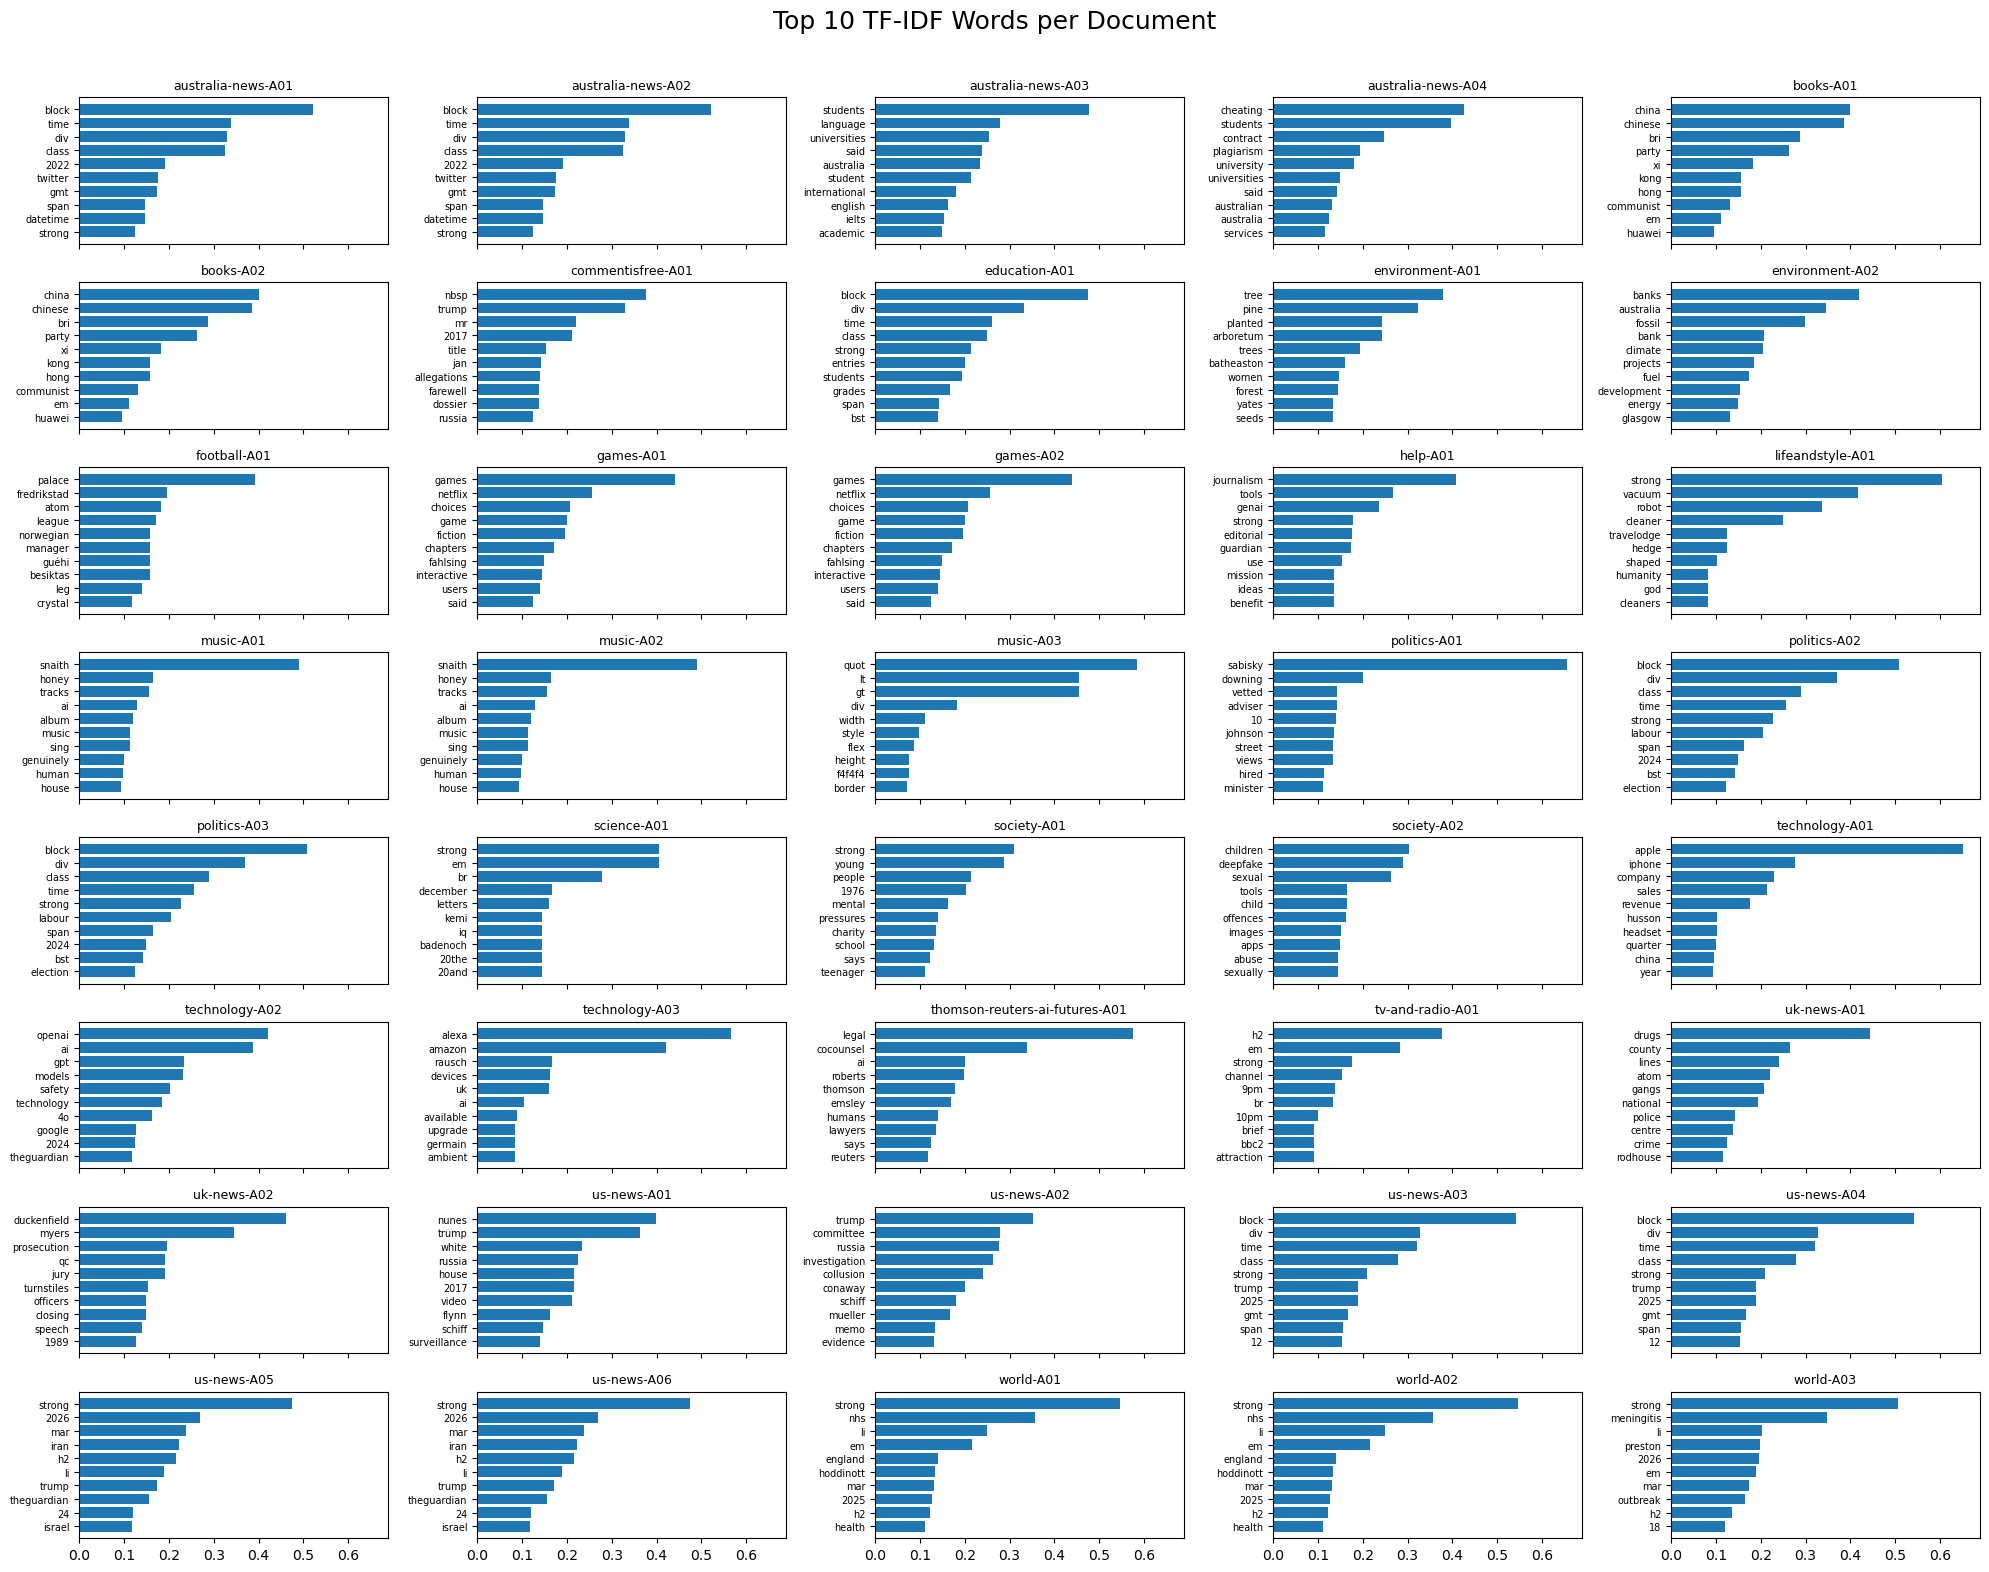

In [8]:
# top TF-IDF terms by document plot for all articles
import matplotlib.pyplot as plt
import math

docs = tfidf_df.index
n_docs = len(docs)

ncols = 5
nrows = math.ceil(n_docs / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 16), sharex=True)

axes = axes.flatten()

# global max TF-IDF (for consistent scaling)
global_max = tfidf_df.apply(lambda row: row.nlargest(10).max(), axis=1).max()

for ax, doc_id in zip(axes, docs):
    top10 = tfidf_df.loc[doc_id].nlargest(10).sort_values()

    ax.barh(top10.index, top10.values)
    ax.set_title(f"{doc_id}", fontsize=9)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_xlim(0, global_max * 1.05)

# remove any unused axes (just in case)
for i in range(n_docs, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Top 10 TF-IDF Words per Document", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Pearson Correlation

Pairwise Pearson Correlation Between Documents Plot

In [9]:
# compute correlation across documents
correlation_matrix = tfidf_df.T.corr(method="pearson")

# print(correlation_matrix.head())

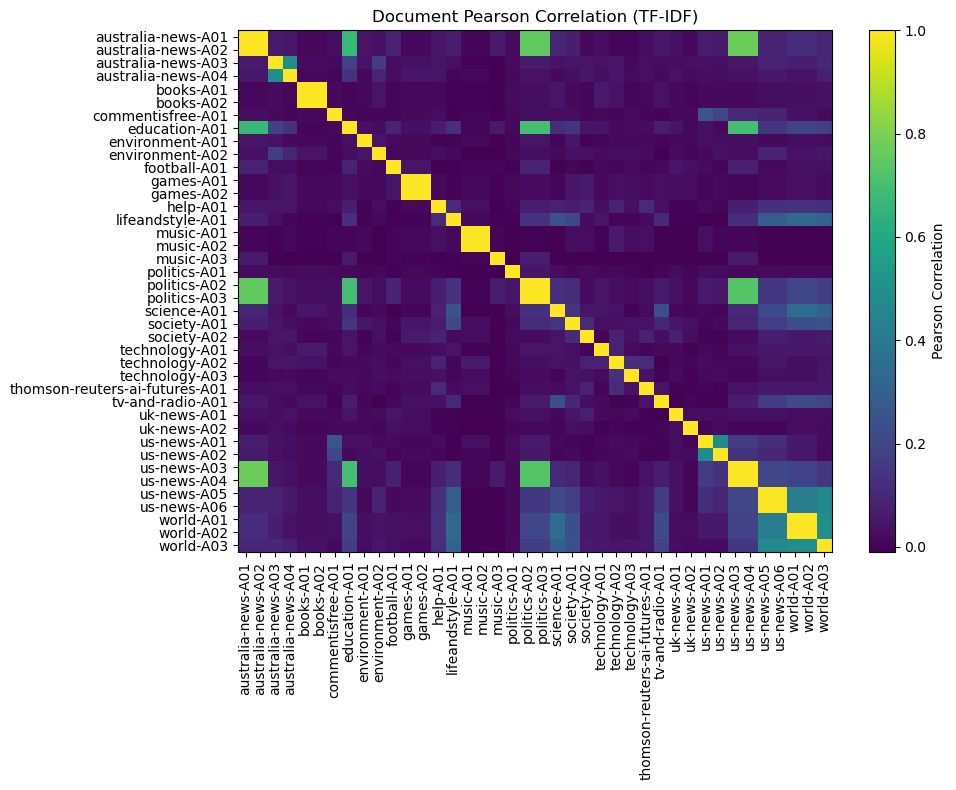

In [10]:
import numpy as np
import matplotlib.pyplot as plt

corr = correlation_matrix.astype(float)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr.values, aspect="auto")

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Pearson Correlation")

# Axis labels
labels = corr.index.astype(str)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_title("Document Pearson Correlation (TF-IDF)")
plt.tight_layout()
plt.show()

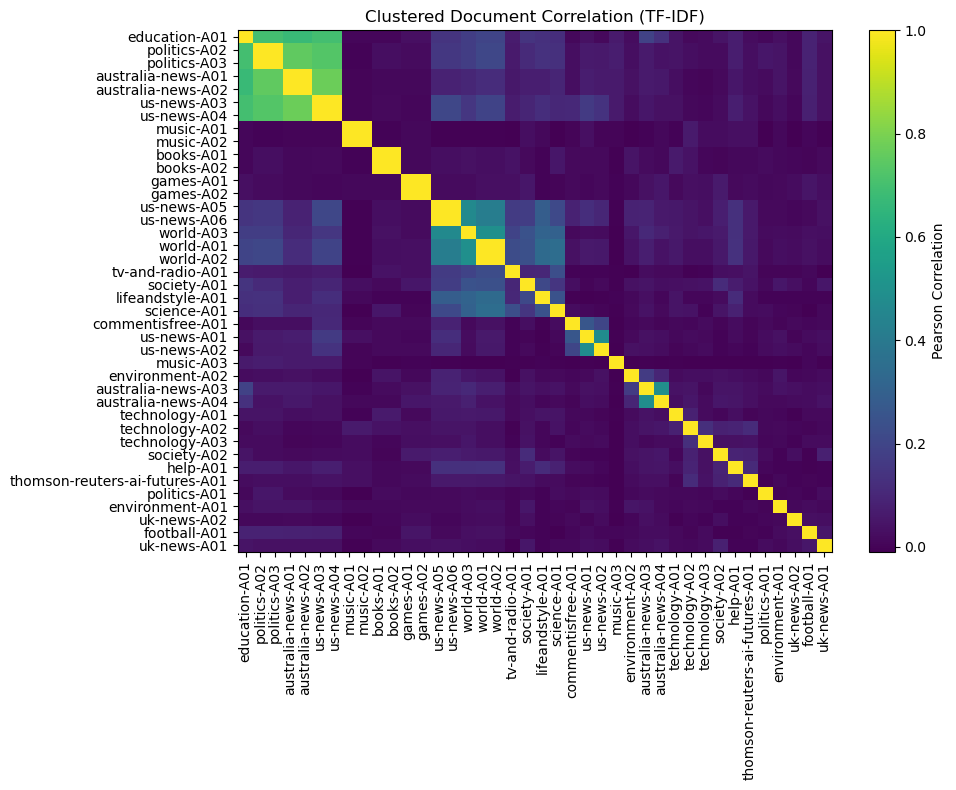

In [11]:
from scipy.cluster.hierarchy import linkage, leaves_list

# Hierarchical clustering
linked = linkage(corr, method="average")
order = leaves_list(linked)

corr_sorted = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_sorted.values, aspect="auto")

plt.colorbar(im).set_label("Pearson Correlation")

sorted_labels = corr_sorted.index.astype(str)

ax.set_xticks(np.arange(len(sorted_labels)))
ax.set_yticks(np.arange(len(sorted_labels)))

ax.set_xticklabels(sorted_labels, rotation=90)
ax.set_yticklabels(sorted_labels)

ax.set_title("Clustered Document Correlation (TF-IDF)")
plt.tight_layout()
plt.show()

# Syntactic Complexity Measures

- could calculate the list of top 30 words ranked by cosine similarity to "artificial intelligence" and "generative AI"
- mean sentence length
- dependent clause density
- clauses per sentence
- dependent clauses per clause/sentence
- coordination per clause/sentence
- complex nominals per clause/sentence


In [12]:
# load model
import spacy
import pandas as pd
import numpy as np

nlp = spacy.load("en_core_web_sm")


In [13]:
def compute_syntactic_profile(text, doc_label="doc"):

    doc = nlp(text)

    sentence_stats = []

    for sent in doc.sents:
        tokens = list(sent)

        token_count = len(tokens)

        # Clause approximation: verbs + auxiliaries
        clauses = sum(1 for t in tokens if t.pos_ in ["VERB", "AUX"])

        # Dependent clauses approximation
        dep_clauses = sum(
            1 for t in tokens if t.dep_ in ["advcl", "ccomp", "xcomp", "acl", "relcl"]
        )

        # Coordination
        coord = sum(1 for t in tokens if t.dep_ == "cc")

        # Complex nominals
        complex_nominals = sum(
            1 for t in tokens if t.dep_ in ["compound", "amod", "nmod", "appos"]
        )

        sentence_stats.append(
            {
                "tokens": token_count,
                "clauses": clauses,
                "dep_clauses": dep_clauses,
                "coord": coord,
                "complex_nominals": complex_nominals,
                "text": sent.text,
            }
        )

    sent_df = pd.DataFrame(sentence_stats)

    if len(sent_df) == 0:
        return None

    MLS = sent_df["tokens"].mean()

    total_sent = len(sent_df)
    total_clauses = sent_df["clauses"].sum()

    if total_clauses == 0:
        total_clauses = np.nan

    C_per_S = sent_df["clauses"].mean()

    DC_per_C = sent_df["dep_clauses"].sum() / total_clauses
    DC_per_S = sent_df["dep_clauses"].sum() / total_sent

    Coord_per_C = sent_df["coord"].sum() / total_clauses
    Coord_per_S = sent_df["coord"].sum() / total_sent

    CN_per_C = sent_df["complex_nominals"].sum() / total_clauses
    CN_per_S = sent_df["complex_nominals"].sum() / total_sent

    # Example sentences
    example_hi = sent_df.sort_values(["dep_clauses", "tokens"], ascending=False).iloc[
        0
    ]["text"]

    example_lo = sent_df.sort_values(["dep_clauses", "tokens"], ascending=True).iloc[0][
        "text"
    ]

    profile = pd.DataFrame(
        [
            {
                "doc": doc_label,
                "MLS": MLS,
                "Clauses_per_Sentence": C_per_S,
                "Dep_Clauses_per_Clause": DC_per_C,
                "Dep_Clauses_per_Sentence": DC_per_S,
                "Coord_per_Clause": Coord_per_C,
                "Coord_per_Sentence": Coord_per_S,
                "Complex_Nominals_per_Clause": CN_per_C,
                "Complex_Nominals_per_Sentence": CN_per_S,
                "example_sentence_high_dep": example_hi,
                "example_sentence_low_dep": example_lo,
            }
        ]
    )

    return profile, sent_df

In [14]:
profiles = []

for _, row in df.iterrows():
    profile, _ = compute_syntactic_profile(row["clean_body"], doc_label=row["short_id"])
    profiles.append(profile)

syntactic_table = pd.concat(profiles, ignore_index=True)

print(syntactic_table.head())

                  doc        MLS  Clauses_per_Sentence  \
0  australia-news-A01  25.153741              4.152381   
1  australia-news-A02  25.153741              4.152381   
2  australia-news-A03  27.367089              4.860759   
3  australia-news-A04  24.800000              4.142857   
4           books-A01  27.282609              3.760870   

   Dep_Clauses_per_Clause  Dep_Clauses_per_Sentence  Coord_per_Clause  \
0                0.374509                  1.555102          0.143512   
1                0.374509                  1.555102          0.143512   
2                0.447917                  2.177215          0.158854   
3                0.410345                  1.700000          0.227586   
4                0.352601                  1.326087          0.329480   

   Coord_per_Sentence  Complex_Nominals_per_Clause  \
0            0.595918                     0.833552   
1            0.595918                     0.833552   
2            0.772152                     0.731771

In [15]:
def compute_syntactic_profile_withsearchterm(text, doc_label="doc", search_term=None):
    doc = nlp(text)

    sentence_stats = []

    for sent in doc.sents:
        tokens = list(sent)
        token_count = len(tokens)

        # Clause approximation: verbs + auxiliaries
        clauses = sum(1 for t in tokens if t.pos_ in ["VERB", "AUX"])

        # Dependent clauses approximation
        dep_clauses = sum(
            1 for t in tokens if t.dep_ in ["advcl", "ccomp", "xcomp", "acl", "relcl"]
        )

        # Coordination
        coord = sum(1 for t in tokens if t.dep_ == "cc")

        # Complex nominals
        complex_nominals = sum(
            1 for t in tokens if t.dep_ in ["compound", "amod", "nmod", "appos"]
        )

        sentence_stats.append(
            {
                "tokens": token_count,
                "clauses": clauses,
                "dep_clauses": dep_clauses,
                "coord": coord,
                "complex_nominals": complex_nominals,
                "text": sent.text,
            }
        )

    sent_df = pd.DataFrame(sentence_stats)

    if len(sent_df) == 0:
        return None, None

    MLS = sent_df["tokens"].mean()
    total_sent = len(sent_df)
    total_clauses = sent_df["clauses"].sum()
    if total_clauses == 0:
        total_clauses = np.nan

    C_per_S = sent_df["clauses"].mean()
    DC_per_C = sent_df["dep_clauses"].sum() / total_clauses
    DC_per_S = sent_df["dep_clauses"].sum() / total_sent
    Coord_per_C = sent_df["coord"].sum() / total_clauses
    Coord_per_S = sent_df["coord"].sum() / total_sent
    CN_per_C = sent_df["complex_nominals"].sum() / total_clauses
    CN_per_S = sent_df["complex_nominals"].sum() / total_sent

    # Example sentences
    example_hi = sent_df.sort_values(["dep_clauses", "tokens"], ascending=False).iloc[
        0
    ]["text"]
    example_lo = sent_df.sort_values(["dep_clauses", "tokens"], ascending=True).iloc[0][
        "text"
    ]

    profile = pd.DataFrame(
        [
            {
                "doc": doc_label,
                "search_term": search_term,  # <-- add search_term here
                "MLS": MLS,
                "Clauses_per_Sentence": C_per_S,
                "Dep_Clauses_per_Clause": DC_per_C,
                "Dep_Clauses_per_Sentence": DC_per_S,
                "Coord_per_Clause": Coord_per_C,
                "Coord_per_Sentence": Coord_per_S,
                "Complex_Nominals_per_Clause": CN_per_C,
                "Complex_Nominals_per_Sentence": CN_per_S,
                "example_sentence_high_dep": example_hi,
                "example_sentence_low_dep": example_lo,
            }
        ]
    )

    return profile, sent_df


# Apply to each document
profiles = []
for _, row in df.iterrows():
    profile, _ = compute_syntactic_profile_withsearchterm(
        row["clean_body"],
        doc_label=row["short_id"],
        search_term=row["search_term"],  # <-- pass search_term here
    )
    if profile is not None:
        profiles.append(profile)

syntactic_table_withsearchterm = pd.concat(profiles, ignore_index=True)
print(syntactic_table_withsearchterm.head())

                  doc    search_term        MLS  Clauses_per_Sentence  \
0  australia-news-A01  generative AI  25.153741              4.152381   
1  australia-news-A02             AI  25.153741              4.152381   
2  australia-news-A03          GenAI  27.367089              4.860759   
3  australia-news-A04          GenAI  24.800000              4.142857   
4           books-A01  generative AI  27.282609              3.760870   

   Dep_Clauses_per_Clause  Dep_Clauses_per_Sentence  Coord_per_Clause  \
0                0.374509                  1.555102          0.143512   
1                0.374509                  1.555102          0.143512   
2                0.447917                  2.177215          0.158854   
3                0.410345                  1.700000          0.227586   
4                0.352601                  1.326087          0.329480   

   Coord_per_Sentence  Complex_Nominals_per_Clause  \
0            0.595918                     0.833552   
1            0

In [16]:
# Example: mean syntactic measures by search_term
syntactic_table_withsearchterm.groupby("search_term").mean(numeric_only=True)

,MLS,Clauses_per_Sentence,Dep_Clauses_per_Clause,Dep_Clauses_per_Sentence,Coord_per_Clause,Coord_per_Sentence,Complex_Nominals_per_Clause,Complex_Nominals_per_Sentence
search_term,,,,,,,,
AI,26.229921,4.184415,0.389739,1.652435,0.181247,0.768316,0.840612,3.560481
GenAI,29.263902,4.756002,0.392301,1.883554,0.194123,0.937869,0.886738,3.990398
artificial intelligence,30.704028,4.995433,0.425886,2.131440,0.156372,0.778273,0.823570,4.052824
generative AI,27.387062,4.393750,0.397105,1.751713,0.183294,0.794690,0.827796,3.635509


In [17]:
# close connection to db
con.close()